In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [18]:
NUM_CHANNELS = 50  # for this, assume 200 channel output
NUM_SAMPLES = 10000  # set this to however many samples you want in train + validation

(200, 200)


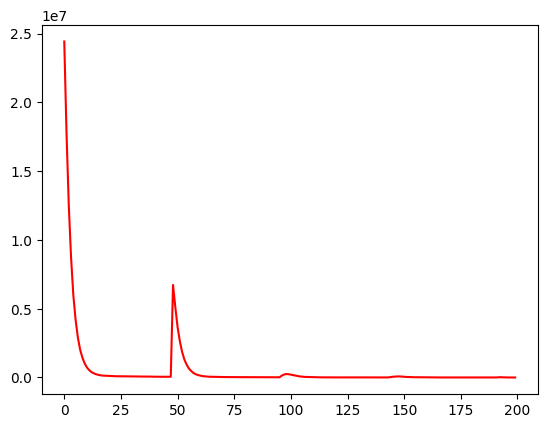

In [19]:
data = np.loadtxt("res/drm/200x200.csv", delimiter=",")
print(data.shape)
plt.plot(data[0], '-r')

## modified pff form

This is modified from the 2022 paper for simplicity. Only 5 parameters.

$$ a_1e^{-a_2x} + a_3e^{\frac{- (x-a_4)^2}{a_5}} $$

In [20]:
def pff_func(x, avals):
    a1, a2, a3, a4, a5 = avals
    return a1 * np.exp(-a2 * x) + a3 * np.exp(- (x-a4)**2 / a5)

In [21]:
data_samples = np.empty((NUM_SAMPLES, NUM_CHANNELS))
energy_bins = np.linspace(50/NUM_CHANNELS, 50, NUM_CHANNELS)

In [22]:
# these are just estimates of the acceptable mean, stdev, and bound parameters for the pff coefficients
pff_func_ranges = np.array([[200, 200, 0.1, 500],
                            [0.25, 2, 0.01, 5],
                            [8, 10, 0, 100],
                            [35, 25, 1, 49],
                            [40, 25, 5, 100]])
    

In [23]:
for i in range(NUM_SAMPLES):
    rng_arr = []
    for param_vals in pff_func_ranges:
        val_guess = np.random.normal(param_vals[0], param_vals[1])
        while val_guess < param_vals[2] or val_guess > param_vals[3]:
            val_guess = np.random.normal(param_vals[0], param_vals[1])
        rng_arr.append(val_guess)
    data_samples[i] = pff_func(energy_bins, rng_arr)

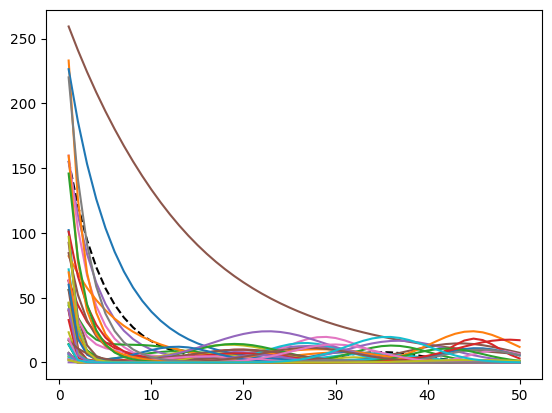

In [24]:
plt.plot(energy_bins, pff_func(energy_bins, pff_func_ranges[:, 0]), '--k')

for i in range(50):
    plt.plot(energy_bins, data_samples[i])

In [25]:
data_samples.shape  # this is the new training set

(10000, 50)